In [1]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "SVM - 33 Features",
        "SVM - 447 Features",
        "Raw Data CNN"
    ],
    "Input": [
        "33 engineered features",
        "414 tactile + 33 engineered",
        "414 raw tactile values"
    ],
    "Validation Accuracy": [
        0.5969,
        0.7617,
        0.6659
    ],
    "Test Accuracy": [
        0.5484,
        0.7608,
        0.6363
    ]
})

results

,Model,Input,Validation Accuracy,Test Accuracy
0,SVM - 33 Features,33 engineered features,0.5969,0.5484
1,SVM - 447 Features,414 tactile + 33 engineered,0.7617,0.7608
2,Raw Data CNN,414 raw tactile values,0.6659,0.6363


In [2]:
results["Test Accuracy (%)"] = (
    results["Test Accuracy"] * 100
)

results

,Model,Input,Validation Accuracy,Test Accuracy,Test Accuracy (%)
0,SVM - 33 Features,33 engineered features,0.5969,0.5484,54.84
1,SVM - 447 Features,414 tactile + 33 engineered,0.7617,0.7608,76.08
2,Raw Data CNN,414 raw tactile values,0.6659,0.6363,63.63


In [3]:
svm_33 = 54.84
svm_447 = 76.08
cnn = 63.63

print(
    f"447-feature SVM vs 33-feature SVM: "
    f"{svm_447 - svm_33:.2f} percentage points"
)

print(
    f"447-feature SVM vs Raw CNN: "
    f"{svm_447 - cnn:.2f} percentage points"
)

447-feature SVM vs 33-feature SVM: 21.24 percentage points
447-feature SVM vs Raw CNN: 12.45 percentage points


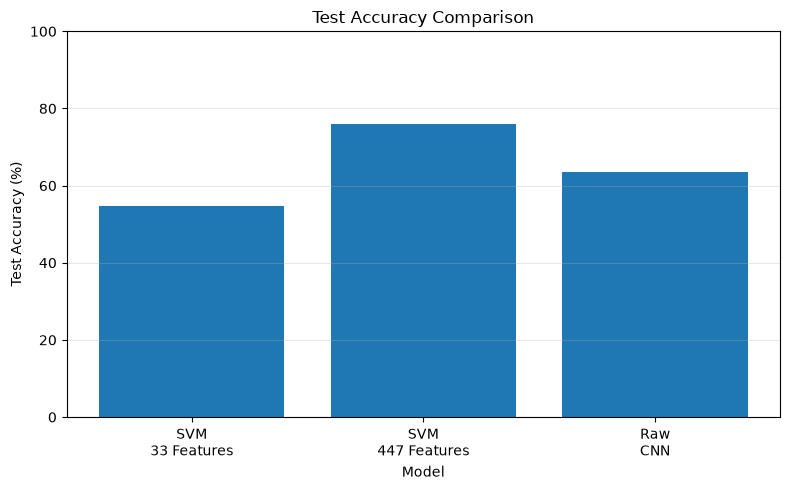

In [4]:
import matplotlib.pyplot as plt

models = [
    "SVM\n33 Features",
    "SVM\n447 Features",
    "Raw\nCNN"
]

accuracies = [
    54.84,
    76.08,
    63.63
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
terrain_names = [
    "asphalt",
    "cork",
    "grass",
    "gravel",
    "lab",
    "laminate_wood",
    "pebble",
    "sand"
]
f1_results = pd.DataFrame({
    "Terrain": terrain_names,

    "SVM-33 F1": [
        47.20,
        30.99,
        61.62,
        49.02,
        47.58,
        54.81,
        58.44,
        88.03
    ],

    "SVM-447 F1": [
        71.00,
        63.00,
        79.00,
        72.00,
        69.00,
        83.00,
        75.00,
        97.00
    ],

    "Raw CNN F1": [
        0,  # we'll fill these from the CNN test report
        0,
        0,
        0,
        0,
        0,
        0,
        0
    ]
})

f1_results

,Terrain,SVM-33 F1,SVM-447 F1,Raw CNN F1
0,asphalt,47.20,71.0,0
1,cork,30.99,63.0,0
2,grass,61.62,79.0,0
3,gravel,49.02,72.0,0
4,lab,47.58,69.0,0
5,laminate_wood,54.81,83.0,0
6,pebble,58.44,75.0,0
7,sand,88.03,97.0,0


In [9]:
f1_results["Improvement"] = (
    f1_results["SVM-447 F1"]
    - f1_results["SVM-33 F1"]
)

f1_results

,Terrain,SVM-33 F1,SVM-447 F1,Raw CNN F1,Improvement
0,asphalt,47.20,71.0,0,23.80
1,cork,30.99,63.0,0,32.01
2,grass,61.62,79.0,0,17.38
3,gravel,49.02,72.0,0,22.98
4,lab,47.58,69.0,0,21.42
5,laminate_wood,54.81,83.0,0,28.19
6,pebble,58.44,75.0,0,16.56
7,sand,88.03,97.0,0,8.97


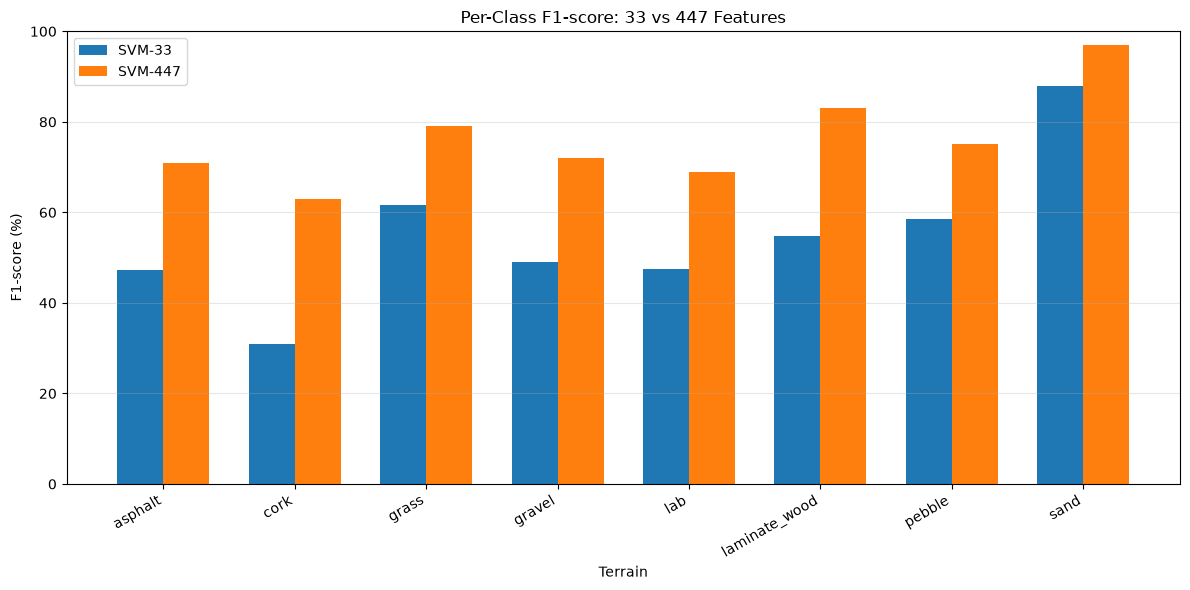

In [11]:
import numpy as np
x = np.arange(len(terrain_names))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    f1_results["SVM-33 F1"],
    width,
    label="SVM-33"
)

plt.bar(
    x + width / 2,
    f1_results["SVM-447 F1"],
    width,
    label="SVM-447"
)

plt.xticks(x, terrain_names, rotation=30, ha="right")
plt.ylabel("F1-score (%)")
plt.xlabel("Terrain")
plt.title("Per-Class F1-score: 33 vs 447 Features")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
best_terrain = f1_results.loc[
    f1_results["SVM-447 F1"].idxmax()
]

worst_terrain = f1_results.loc[
    f1_results["SVM-447 F1"].idxmin()
]

print(
    f"Best performing terrain: "
    f"{best_terrain['Terrain']} "
    f"({best_terrain['SVM-447 F1']:.2f}% F1)"
)

print(
    f"Weakest performing terrain: "
    f"{worst_terrain['Terrain']} "
    f"({worst_terrain['SVM-447 F1']:.2f}% F1)"
)

Best performing terrain: sand (97.00% F1)
Weakest performing terrain: cork (63.00% F1)


## Final Findings

1. The SVM trained using only the 33 engineered features achieved a test accuracy of 54.84%.

2. Adding the 414 raw tactile measurements to the 33 engineered features increased the SVM test accuracy to 76.08%, an improvement of 21.24 percentage points.

3. The Raw Data CNN achieved a test accuracy of 63.63%, which was lower than the combined 447-feature SVM.

4. Among all evaluated models, the SVM using the combined tactile and engineered representation achieved the best test performance.

5. The SVM-447 model showed a very small validation-test difference of approximately 0.09 percentage points, indicating consistent performance between the validation and held-out test sets.

6. Sand was the easiest terrain for the SVM-447 model to classify, while cork was the most challenging based on F1-score.

7. The results indicate that the raw tactile measurements provide useful discriminative information beyond the 33 engineered features for this dataset.

8. These findings demonstrate that tactile sensor data can be used for automated terrain classification and can potentially support terrain-aware decision making for small legged robots.

## Limitations

1. The dataset contains 5,990 samples collected from a specific tactile sensing setup, so generalization to other robots and sensor configurations has not been established.

2. The experiments use eight predefined terrain classes. Performance on unseen terrain types was not evaluated.

3. The experiments are offline classification experiments and do not include real-time deployment on a physical legged robot.

4. The Raw Data CNN did not outperform the SVM models under the selected architecture and training configuration. More extensive CNN architecture and hyperparameter exploration could potentially improve its performance.

5. The evaluation uses a fixed train-validation-test split. Although the split was stratified and reproducible, evaluation across multiple independent splits could provide a stronger estimate of generalization.

6. The study evaluates classification accuracy but does not measure downstream robotic performance such as gait adaptation, stability, energy consumption, or navigation performance.

## Conclusion

This project investigated terrain classification for small legged robots using tactile sensor data and deep learning-based methods.

Three models were evaluated: an RBF-SVM using 33 engineered features, an RBF-SVM using the combined 447-dimensional tactile and engineered representation, and a CNN operating directly on the raw tactile measurements.

The combined 447-feature SVM achieved the best performance with a test accuracy of 76.08%. It outperformed the 33-feature SVM by 21.24 percentage points and the Raw Data CNN by 12.45 percentage points.

The results demonstrate that the tactile measurements contain useful information for distinguishing terrain types and that combining raw tactile measurements with engineered features can provide a strong representation for terrain classification on this dataset.

The work provides a reproducible experimental foundation for future development toward real-time terrain-aware perception and adaptive locomotion for small legged robots.

In [13]:
results.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Saved model_comparison.csv")

Saved model_comparison.csv


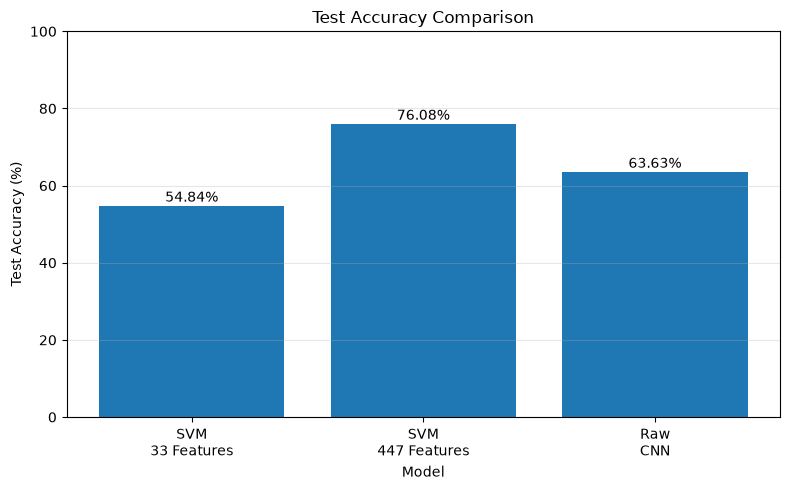

In [15]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    models,
    accuracies
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../results/figures/test_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

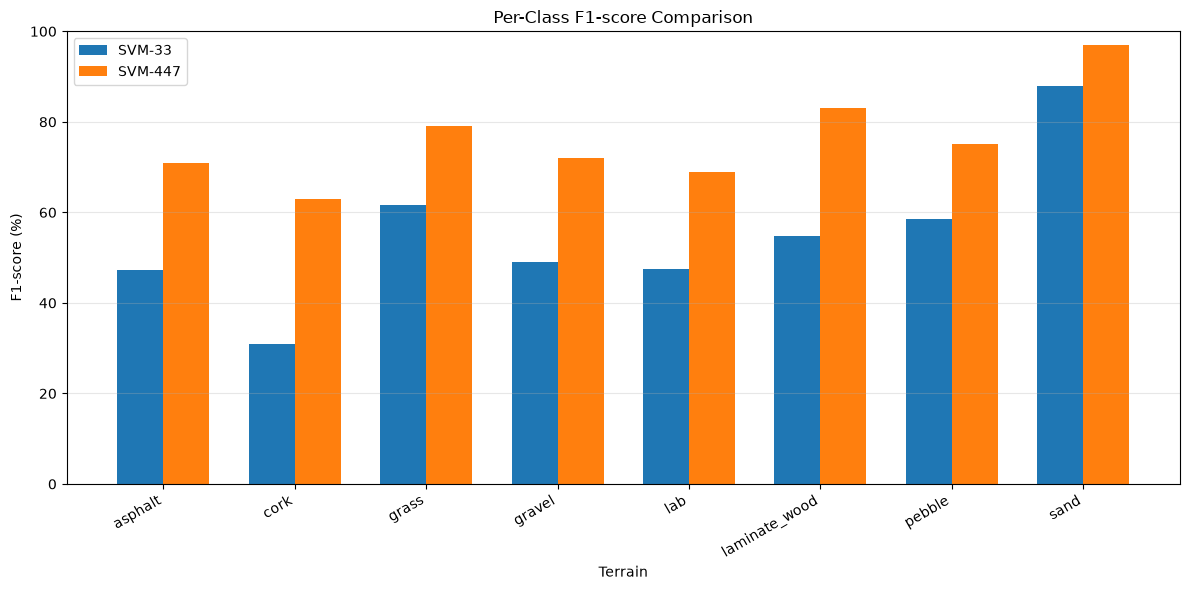

In [16]:
x = np.arange(len(terrain_names))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    f1_results["SVM-33 F1"],
    width,
    label="SVM-33"
)

plt.bar(
    x + width / 2,
    f1_results["SVM-447 F1"],
    width,
    label="SVM-447"
)

plt.xticks(
    x,
    terrain_names,
    rotation=30,
    ha="right"
)

plt.ylabel("F1-score (%)")
plt.xlabel("Terrain")
plt.title("Per-Class F1-score Comparison")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/figures/per_class_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
#error analysis

error_analysis = pd.DataFrame({
    "Terrain": [
        "asphalt",
        "cork",
        "grass",
        "gravel",
        "lab",
        "laminate_wood",
        "pebble",
        "sand"
    ],
    "SVM-33 F1": [
        0.4720,
        0.3099,
        0.6162,
        0.4902,
        0.4758,
        0.5481,
        0.5844,
        0.8803
    ],
    "SVM-447 F1": [
        0.71,
        0.63,
        0.79,
        0.72,
        0.69,
        0.83,
        0.75,
        0.97
    ],
    "Raw CNN F1": [
        0.6220,
        0.6009,
        0.8387,
        0.5484,
        0.4574,
        0.5887,
        0.6996,
        0.9391
    ]
})

error_analysis


,Terrain,SVM-33 F1,SVM-447 F1,Raw CNN F1
0,asphalt,0.4720,0.71,0.6220
1,cork,0.3099,0.63,0.6009
2,grass,0.6162,0.79,0.8387
3,gravel,0.4902,0.72,0.5484
4,lab,0.4758,0.69,0.4574
5,laminate_wood,0.5481,0.83,0.5887
6,pebble,0.5844,0.75,0.6996
7,sand,0.8803,0.97,0.9391


In [19]:
for column in ["SVM-33 F1", "SVM-447 F1", "Raw CNN F1"]:
    hardest = error_analysis.loc[error_analysis[column].idxmin()]
    
    print(f"{column}")
    print(f"Hardest terrain: {hardest['Terrain']}")
    print(f"F1-score: {hardest[column]:.2f}")
    print()

SVM-33 F1
Hardest terrain: cork
F1-score: 0.31

SVM-447 F1
Hardest terrain: cork
F1-score: 0.63

Raw CNN F1
Hardest terrain: lab
F1-score: 0.46



In [20]:
for column in ["SVM-33 F1", "SVM-447 F1", "Raw CNN F1"]:
    strongest = error_analysis.loc[error_analysis[column].idxmax()]
    
    print(f"{column}")
    print(f"Strongest terrain: {strongest['Terrain']}")
    print(f"F1-score: {strongest[column]:.2f}")
    print()

SVM-33 F1
Strongest terrain: sand
F1-score: 0.88

SVM-447 F1
Strongest terrain: sand
F1-score: 0.97

Raw CNN F1
Strongest terrain: sand
F1-score: 0.94



## Error Analysis

The classification results show that terrain difficulty varies considerably across terrain classes and model architectures.

### Sand

Sand is consistently the easiest terrain to classify. It achieves the highest F1-score across all three models. This suggests that the tactile response generated by sand contains relatively distinctive patterns that can be separated from the other terrain types.

### Grass

Grass also shows strong classification performance, particularly for the Raw Data CNN and SVM-447. The temporal tactile measurements appear to contain useful information for distinguishing grass from several other surfaces.

### Cork

Cork is one of the most difficult terrains to classify. Its performance remains relatively low even when using the complete 447-dimensional representation. This indicates that the tactile characteristics of cork may overlap with those of other terrain types.

### Gravel

Gravel presents another challenging case, particularly for the Raw Data CNN. The irregular contact patterns produced by gravel may result in greater variation within the same terrain class, making consistent classification more difficult.

### Lab and Laminate Wood

Lab and laminate wood show confusion with other relatively smooth or hard surfaces. These terrains may produce similar tactile responses, making their boundaries less distinct in the feature space.

### Overall Error Pattern

The main classification errors occur between terrains that produce similar tactile responses. The SVM-447 model reduces many of these errors by combining the raw tactile measurements with the engineered features. However, some difficult terrain classes, particularly cork, remain challenging.

Overall, the errors indicate that terrain classification performance depends not only on the model architecture but also on the degree of separability between the tactile characteristics of different terrain types.

In [21]:
print("Key Error Analysis Findings")
print("-" * 40)

print("1. Sand is the strongest-performing terrain across all models.")
print("2. Cork is consistently among the most difficult terrains.")
print("3. SVM-447 substantially improves classification across most terrain classes.")
print("4. Errors are concentrated among terrains with similar tactile responses.")
print("5. Raw CNN performs strongly on sand and grass but struggles more on some difficult classes.")

Key Error Analysis Findings
----------------------------------------
1. Sand is the strongest-performing terrain across all models.
2. Cork is consistently among the most difficult terrains.
3. SVM-447 substantially improves classification across most terrain classes.
4. Errors are concentrated among terrains with similar tactile responses.
5. Raw CNN performs strongly on sand and grass but struggles more on some difficult classes.
